# Best Model — RoBERTa-base with Data Augmentation (Two-Phase)

## Phase 1 — Train + eval → `dev.txt`
- Training data: official train split + `augmented_train_data.csv`
- Evaluated on official dev split; best checkpoint saved by macro-F1
- Produces `dev.txt` (2094 lines)

## Phase 2 — Full retrain → `test.txt`
- Training data: train + aug_train + **dev + aug_dev** (no held-out set)
- Fresh `roberta-base` trained for the same number of epochs
- Produces `test.txt` (3832 lines)

**Model**: `roberta-base` · **Optimiser**: AdamW (cosine + 10% warmup) · **Loss**: class-weighted CE

In [1]:
!pip install contractions python-dotenv huggingface_hub

In [2]:
import os
import re
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
import seaborn as sns
import contractions

from dotenv import load_dotenv
from huggingface_hub import login

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    set_seed,
)

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

/home/wowthecoder/imperial-nlp-cw/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [3]:
load_dotenv()
hf_token = os.getenv('HF_TOKEN')
if hf_token:
    login(token=hf_token)
    print('HF token loaded.')
else:
    print('HF_TOKEN not found; proceeding without login.')

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HF token loaded.


In [4]:
# ============================================================
# Configuration
# ============================================================
MODEL_NAME  = 'roberta-base'
MAX_LENGTH  = 256
NUM_EPOCHS  = 5

# Notebook lives in BestModel/; data files are one level up
DATA_ROOT      = '..'
TSV_PATH       = os.path.join(DATA_ROOT, 'dontpatronizeme_pcl.tsv')
TRAIN_IDS_PATH = os.path.join(DATA_ROOT, 'train', 'train_semeval_parids-labels.csv')
DEV_IDS_PATH   = os.path.join(DATA_ROOT, 'train', 'dev_semeval_parids-labels.csv')
TEST_PATH      = os.path.join(DATA_ROOT, 'test', 'task4_test.tsv')
AUG_TRAIN_PATH = os.path.join(DATA_ROOT, 'data_augmentation', 'augmented_train_data.csv')
AUG_DEV_PATH   = os.path.join(DATA_ROOT, 'data_augmentation', 'augmented_dev_data.csv')

# Phase 1 checkpoint dir (train split only)
RUN_NAME_P1 = 'checkpoints/phase1'
# Phase 2 checkpoint dir (full data)
RUN_NAME_P2 = 'checkpoints/phase2'

DEV_TXT_PATH  = 'dev.txt'
TEST_TXT_PATH = 'test.txt'

os.makedirs(RUN_NAME_P1, exist_ok=True)
os.makedirs(RUN_NAME_P2, exist_ok=True)
print('Checkpoint dirs created.')

Checkpoint dirs created.


In [5]:
# ============================================================
# Helper functions
# ============================================================
def load_task1(tsv_path: str) -> pd.DataFrame:
    """Load labelled PCL dataset; binarise labels (0/1 -> 0, 2/3/4 -> 1)."""
    rows = []
    with open(tsv_path, encoding='utf-8') as f:
        for line in f.readlines()[4:]:
            parts = line.rstrip('\n').split('\t')
            if len(parts) < 6:
                continue
            orig_label = parts[-1]
            rows.append({
                'par_id':  str(parts[0]),
                'art_id':  parts[1],
                'keyword': parts[2],
                'country': parts[3],
                'text':    parts[4],
                'label':   0 if orig_label in {'0', '1'} else 1,
            })
    return pd.DataFrame(rows)


def load_test_tsv(test_path: str) -> pd.DataFrame:
    """Load unlabelled test set (tab-separated, no header)."""
    rows = []
    with open(test_path, encoding='utf-8') as f:
        for line in f:
            parts = line.rstrip('\n').split('\t')
            if len(parts) < 5:
                continue
            rows.append({
                'par_id':  parts[0],
                'art_id':  parts[1],
                'keyword': parts[2],
                'country': parts[3],
                'text':    parts[4],
            })
    return pd.DataFrame(rows)


def load_aug_csv(path: str) -> pd.DataFrame:
    """Load an augmented data CSV, drop stray header rows, cast label to int."""
    aug = pd.read_csv(path, dtype={'par_id': str})
    aug = aug[aug['label'].astype(str) != 'label'].copy()
    aug['label'] = aug['label'].astype(int)
    if 'clean_text' in aug.columns:
        aug['clean_text'] = aug['clean_text'].fillna(aug['text'].apply(preprocess_text))
    else:
        aug['clean_text'] = aug['text'].apply(preprocess_text)
    aug['model_text'] = make_model_text(aug)
    return aug[['par_id', 'keyword', 'country', 'text', 'clean_text', 'model_text', 'label']]


def preprocess_text(text: str) -> str:
    text = str(text)
    text = contractions.fix(text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def make_model_text(frame: pd.DataFrame) -> pd.Series:
    kw  = frame['keyword'].fillna('').astype(str).str.strip()
    cc  = frame['country'].fillna('').astype(str).str.strip()
    txt = frame['clean_text'].fillna('').astype(str).str.strip()
    return kw + ' </s> ' + cc + ' </s> ' + txt

In [6]:
# ============================================================
# Load labelled dataset + preprocess
# ============================================================
df = load_task1(TSV_PATH)
df['clean_text'] = df['text'].apply(preprocess_text)
df['model_text'] = make_model_text(df)

print(f'Full labelled dataset: {len(df):,} rows')
print(df['label'].value_counts().rename({0: 'No-PCL', 1: 'PCL'}))

Full labelled dataset: 10,469 rows
label
No-PCL    9476
PCL        993
Name: count, dtype: int64


In [7]:
# ============================================================
# Official train / dev split
# ============================================================
train_ids_df = pd.read_csv(TRAIN_IDS_PATH, dtype={'par_id': str})
dev_ids_df   = pd.read_csv(DEV_IDS_PATH,   dtype={'par_id': str})

train_par_ids = set(train_ids_df['par_id'].astype(str))
dev_par_ids   = set(dev_ids_df['par_id'].astype(str))

train_base_df = df[df['par_id'].isin(train_par_ids)].copy().reset_index(drop=True)

# Dev set ordered exactly as the official split file (required for correct dev.txt)
dev_base_df = (
    dev_ids_df[['par_id']]
    .merge(df[df['par_id'].isin(dev_par_ids)], on='par_id', how='left')
    .reset_index(drop=True)
)

# Leftover samples not in either split go to train
leftover = df[~df['par_id'].isin(train_par_ids | dev_par_ids)]
if len(leftover):
    train_base_df = pd.concat([train_base_df, leftover], ignore_index=True)
    print(f'Appended {len(leftover):,} leftover samples to train.')

print(f'Train base: {len(train_base_df):,} | PCL={int((train_base_df.label==1).sum()):,} | No-PCL={int((train_base_df.label==0).sum()):,}')
print(f'Dev base:   {len(dev_base_df):,}  | PCL={int((dev_base_df.label==1).sum()):,}  | No-PCL={int((dev_base_df.label==0).sum()):,}')

Train base: 8,375 | PCL=794 | No-PCL=7,581
Dev base:   2,094  | PCL=199  | No-PCL=1,895


In [8]:
# ============================================================
# Load augmented data
# ============================================================
aug_train_df = load_aug_csv(AUG_TRAIN_PATH)
aug_dev_df   = load_aug_csv(AUG_DEV_PATH)

print(f'aug_train : {len(aug_train_df):,} rows | PCL={int((aug_train_df.label==1).sum()):,}')
print(f'aug_dev   : {len(aug_dev_df):,} rows  | PCL={int((aug_dev_df.label==1).sum()):,}')

aug_train : 5,558 rows | PCL=5,558
aug_dev   : 995 rows  | PCL=995


In [9]:
# ============================================================
# Tokenisation helpers
# ============================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)


def build_dataset(frame: pd.DataFrame, has_labels: bool = True) -> Dataset:
    cols = ['model_text', 'label'] if has_labels else ['model_text']
    ds = (
        Dataset.from_pandas(
            frame[cols].rename(columns={'model_text': 'text'}),
            preserve_index=False,
        )
        .map(tokenize, batched=True, remove_columns=['text'])
    )
    if has_labels:
        ds = ds.rename_column('label', 'labels')
        ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
    else:
        ds.set_format(type='torch', columns=['input_ids', 'attention_mask'])
    return ds

In [10]:
# ============================================================
# Evaluation metrics (macro-F1 focused)
# ============================================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'f1_macro':        f1_score(labels, preds, average='macro',  zero_division=0),
        'precision_macro': precision_score(labels, preds, average='macro', zero_division=0),
        'recall_macro':    recall_score(labels, preds, average='macro', zero_division=0),
    }

In [11]:
# ============================================================
# Custom Trainer with class-weighted CrossEntropyLoss
# ============================================================
class WeightedCETrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = (
            torch.tensor(class_weights, dtype=torch.float)
            if class_weights is not None else None
        )

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        logits  = outputs.logits
        weight  = self.class_weights.to(logits.device) if self.class_weights is not None else None
        loss    = nn.CrossEntropyLoss(weight=weight)(logits, labels)
        return (loss, outputs) if return_outputs else loss

---
## Phase 1 — Train on train split + augmented train data
Trains with dev as validation set; best checkpoint (by macro-F1) is restored at end.

In [12]:
# ============================================================
# Phase 1 training set: train_base + aug_train
# ============================================================
p1_train_df = pd.concat([train_base_df, aug_train_df], ignore_index=True)
p1_train_df = p1_train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

p1_cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=p1_train_df['label'].values)

print(f'Phase 1 train: {len(p1_train_df):,} | PCL={int((p1_train_df.label==1).sum()):,} | No-PCL={int((p1_train_df.label==0).sum()):,}')
print(f'Class weights -> No-PCL: {p1_cw[0]:.4f},  PCL: {p1_cw[1]:.4f}')

p1_train_ds = build_dataset(p1_train_df)
p1_dev_ds   = build_dataset(dev_base_df)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(p1_train_ds)
print(p1_dev_ds)

Phase 1 train: 13,933 | PCL=6,352 | No-PCL=7,581
Class weights -> No-PCL: 0.9189,  PCL: 1.0967


Map: 100%|██████████| 2094/2094 [00:00<00:00, 28813.88 examples/s]

Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 13933
})
Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 2094
})


In [13]:
# ============================================================
# Phase 1 model + trainer
# ============================================================
p1_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

p1_args = TrainingArguments(
    output_dir=RUN_NAME_P1,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type='cosine',
    optim='adamw_torch',
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    save_total_limit=2,
    report_to='none',
    seed=SEED,
)

p1_trainer = WeightedCETrainer(
    model=p1_model,
    args=p1_args,
    train_dataset=p1_train_ds,
    eval_dataset=p1_dev_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    class_weights=p1_cw.tolist()
)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 436.14it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

In [14]:
p1_train_result = p1_trainer.train()
print(p1_train_result)

Epoch,Training Loss,Validation Loss,F1 Macro,Precision Macro,Recall Macro
1,0.424748,0.230592,0.734114,0.788083,0.700639
2,0.154550,0.356140,0.784724,0.801705,0.770073
3,0.039247,0.529054,0.784724,0.801705,0.770073
4,0.019583,0.571470,0.767732,0.830626,0.728667
5,0.003037,0.591669,0.772494,0.829254,0.735677


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.89s/it]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

TrainOutput(global_step=4355, training_loss=0.11091766324574309, metrics={'train_runtime': 787.705, 'train_samples_per_second': 88.44, 'train_steps_per_second': 5.529, 'total_flos': 4815601396279560.0, 'train_loss': 0.11091766324574309, 'epoch': 5.0})


Phase 1 dev metrics (best checkpoint):
  eval_loss: 0.3577
  eval_f1_macro: 0.7857
  eval_precision_macro: 0.8036
  eval_recall_macro: 0.7703
  eval_runtime: 7.8648
  eval_samples_per_second: 266.2510
  eval_steps_per_second: 8.3920
  epoch: 5.0000

              precision    recall  f1-score   support

      No-PCL     0.9557    0.9678    0.9617      1895
         PCL     0.6514    0.5729    0.6096       199

    accuracy                         0.9303      2094
   macro avg     0.8036    0.7703    0.7857      2094
weighted avg     0.9268    0.9303    0.9283      2094



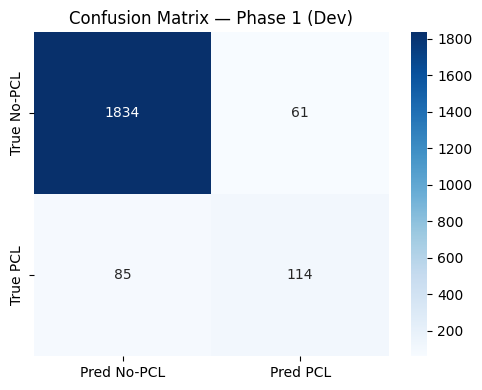

In [15]:
# ============================================================
# Phase 1 evaluation (best checkpoint)
# ============================================================
p1_eval = p1_trainer.evaluate()
print('Phase 1 dev metrics (best checkpoint):')
for k, v in p1_eval.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

p1_pred_out = p1_trainer.predict(p1_dev_ds)
y_true = p1_pred_out.label_ids
y_pred = np.argmax(p1_pred_out.predictions, axis=-1)

print('\n' + classification_report(y_true, y_pred, target_names=['No-PCL', 'PCL'], digits=4, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred No-PCL', 'Pred PCL'],
            yticklabels=['True No-PCL', 'True PCL'])
plt.title('Confusion Matrix — Phase 1 (Dev)')
plt.tight_layout()
plt.savefig(os.path.join(RUN_NAME_P1, 'confusion_matrix.png'), dpi=150)
plt.show()

In [16]:
# ============================================================
# Generate dev.txt  (official dev split order)
# ============================================================
# dev_base_df was ordered to match dev_ids_df, so p1_dev_ds rows align directly.
dev_preds = y_pred.tolist()

assert set(dev_preds).issubset({0, 1}), 'Unexpected values in dev predictions'
assert len(dev_preds) == len(dev_base_df), (
    f'Dev count mismatch: {len(dev_preds)} vs {len(dev_base_df)}'
)

with open(DEV_TXT_PATH, 'w') as f:
    f.write('\n'.join(str(p) for p in dev_preds) + '\n')

print(f'Written {len(dev_preds):,} predictions -> {DEV_TXT_PATH}')

Written 2,094 predictions -> dev.txt


---
## Phase 2 — Full retrain on all labelled data
Train + aug_train + dev + aug_dev combined; no held-out validation set.
A **fresh** `roberta-base` is used (same hyperparameters as Phase 1).

In [17]:
# ============================================================
# Phase 2 training set: train_base + aug_train + dev_base + aug_dev
# ============================================================
p2_train_df = pd.concat(
    [train_base_df, aug_train_df, dev_base_df, aug_dev_df],
    ignore_index=True,
).sample(frac=1, random_state=SEED).reset_index(drop=True)

p2_cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=p2_train_df['label'].values)

print(f'Phase 2 train: {len(p2_train_df):,} | PCL={int((p2_train_df.label==1).sum()):,} | No-PCL={int((p2_train_df.label==0).sum()):,}')
print(f'Class weights -> No-PCL: {p2_cw[0]:.4f},  PCL: {p2_cw[1]:.4f}')

p2_train_ds = build_dataset(p2_train_df)
print(p2_train_ds)

Phase 2 train: 17,022 | PCL=7,546 | No-PCL=9,476
Class weights -> No-PCL: 0.8982,  PCL: 1.1279


Map: 100%|██████████| 17022/17022 [00:00<00:00, 26593.85 examples/s]

Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 17022
})


In [ ]:
# ============================================================
# Phase 2 model + trainer  (fresh roberta-base, no eval set)
# ============================================================
p2_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

p2_args = TrainingArguments(
    output_dir=RUN_NAME_P2,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type='cosine',
    optim='adamw_torch',
    eval_strategy='no',        # no validation set in Phase 2
    save_strategy='no',        # save only the final model below
    report_to='none',
    seed=SEED,
)

p2_trainer = WeightedCETrainer(
    model=p2_model,
    args=p2_args,
    train_dataset=p2_train_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    class_weights=p2_cw.tolist(),
)

print('Phase 2 trainer configured.')

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 482.99it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Phase 2 trainer configured.


In [19]:
p2_train_result = p2_trainer.train()
print(p2_train_result)

# Save final Phase 2 model
p2_final_dir = os.path.join(RUN_NAME_P2, 'final')
p2_trainer.save_model(p2_final_dir)
tokenizer.save_pretrained(p2_final_dir)
print(f'Phase 2 model saved to: {p2_final_dir}')

Step,Training Loss
500,0.462488
1000,0.265940
1500,0.169916
2000,0.122792
2500,0.071821
3000,0.057644
3500,0.024132
4000,0.010898
4500,0.005198
5000,0.004596


TrainOutput(global_step=5320, training_loss=0.11240312362411865, metrics={'train_runtime': 1132.8788, 'train_samples_per_second': 75.127, 'train_steps_per_second': 4.696, 'total_flos': 5865073285016040.0, 'train_loss': 0.11240312362411865, 'epoch': 5.0})


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.77s/it]

Phase 2 model saved to: checkpoints/phase2/final


In [20]:
# ============================================================
# Generate test.txt  (3832 predictions in test file order)
# ============================================================
test_df = load_test_tsv(TEST_PATH)
test_df['clean_text'] = test_df['text'].apply(preprocess_text)
test_df['model_text'] = make_model_text(test_df)

test_ds       = build_dataset(test_df, has_labels=False)
test_pred_out = p2_trainer.predict(test_ds)
test_preds    = np.argmax(test_pred_out.predictions, axis=-1).tolist()

assert set(test_preds).issubset({0, 1}), 'Unexpected values in test predictions'
assert len(test_preds) == len(test_df), (
    f'Test count mismatch: {len(test_preds)} vs {len(test_df)}'
)

with open(TEST_TXT_PATH, 'w') as f:
    f.write('\n'.join(str(p) for p in test_preds) + '\n')

print(f'Written {len(test_preds):,} predictions -> {TEST_TXT_PATH}  (expected 3832)')

Map: 100%|██████████| 3832/3832 [00:00<00:00, 23912.47 examples/s]


Written 3,832 predictions -> test.txt  (expected 3832)


In [21]:
# ============================================================
# Sanity checks on output files
# ============================================================
for path in [DEV_TXT_PATH, TEST_TXT_PATH]:
    with open(path) as f:
        lines = [l.strip() for l in f if l.strip()]
    print(f'{path:12s}: lines={len(lines):,}, unique_labels={sorted(set(lines))}')

dev.txt     : lines=2,094, unique_labels=['0', '1']
test.txt    : lines=3,832, unique_labels=['0', '1']
